<a href="https://www.kaggle.com/code/jaygor13/genome-mutation?scriptVersionId=304177647" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# ChromoDiff: Generative Zero-Shot Pathogenicity Prediction
### Discrete Genomic Diffusion — Kaggle Training Notebook

**Notebook structure:**
1. Environment Setup & Imports
2. Diffusion Hyperparameters & Beta Schedule
3. Dataset & DataLoader
4. Forward Diffusion Process (`q_sample`)
5. Model Architecture (Sinusoidal Embeddings → Dilated ResNet)
6. Training Loop (AMP + Gradient Clipping + LR Scheduler + Checkpointing)
7. GVES Inference Scorer (Task 1)
8. Validation Pipeline — AUROC / AUPRC (Task 2)

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Environment Setup & Imports
# ─────────────────────────────────────────────────────────────────────────────
# FIX: All imports consolidated here so every subsequent cell can rely on them.
# Previously imports were scattered across cells causing NameErrors on fresh runs.

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast   # FIX: AMP — halves VRAM

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device : {device}")
if device.type == "cuda":
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
    print(f"VRAM total    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── List input files ──────────────────────────────────────────────────────────
print("\nAvailable input files:")
for dirpath, _, filenames in os.walk('/kaggle/input'):
    for fname in filenames:
        print(" ", os.path.join(dirpath, fname))

Using device : cuda
GPU           : Tesla P100-PCIE-16GB
VRAM total    : 17.1 GB

Available input files:
  /kaggle/input/datasets/jaygor13/genodiff-processed-data/Y_labels.npy
  /kaggle/input/datasets/jaygor13/genodiff-processed-data/X_corrupted.npy
  /kaggle/input/datasets/jaygor13/genodiff-processed-data/X_healthy.npy


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Global Hyperparameters
# ─────────────────────────────────────────────────────────────────────────────

# Diffusion schedule
T_STEPS    = 1000
BETA_START = 1e-4
BETA_END   = 0.02
VOCAB_SIZE = 5        # A=0 C=1 G=2 T=3 N=4
SEQ_LEN    = 1024

# Model
# FIX: hidden_dim 128 → 256.  The original 1.2M-param model saturated within
# ~15 epochs on this dataset.  Doubling the width gives 4.8M params and
# substantially more representational capacity for genomic syntax.
HIDDEN_DIM  = 256

# Training
BATCH_SIZE    = 64
EPOCHS        = 10      # change freely; scheduler adapts automatically
LEARNING_RATE = 1e-2
GRAD_CLIP     = 1.0
WARMUP_EPOCHS = 5       # FIX: linear LR warmup before cosine decay kicks in

# ── Beta schedule ─────────────────────────────────────────────────────────────
betas          = torch.linspace(BETA_START, BETA_END, T_STEPS).to(device)
alphas         = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0).to(device)

print(f"Beta schedule : {BETA_START} → {BETA_END} over {T_STEPS} steps")
print(f"ᾱ at t=1      : {alphas_cumprod[0].item():.5f}")
print(f"ᾱ at t=500    : {alphas_cumprod[499].item():.5f}")
print(f"ᾱ at t=1000   : {alphas_cumprod[-1].item():.6f}")


Beta schedule : 0.0001 → 0.02 over 1000 steps
ᾱ at t=1      : 0.99990
ᾱ at t=500    : 0.07859
ᾱ at t=1000   : 0.000040


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Dataset & DataLoader
# ─────────────────────────────────────────────────────────────────────────────
# FIX: Added pin_memory=True and num_workers=4 for async CPU→GPU DMA transfers.
# pin_memory lets CUDA copy data directly from page-locked host memory,
# while num_workers prefetches batches in parallel — both are free speed wins.

class GenomicDataset(Dataset):
    """Wraps a (N, 1024) long tensor of healthy hg38 genome windows."""
    def __init__(self, data_tensor: torch.Tensor):
        self.data = data_tensor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


# ── Load healthy training data ────────────────────────────────────────────────
DATA_DIR = '/kaggle/input/datasets/jaygor13/genodiff-processed-data'

x_healthy_raw    = np.load(os.path.join(DATA_DIR, 'X_healthy.npy'))
X_healthy_tensor = torch.tensor(x_healthy_raw, dtype=torch.long)  # must be Long for nn.Embedding

train_dataset = GenomicDataset(X_healthy_tensor)
train_loader  = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    drop_last   = True,
    pin_memory  = True,    # FIX: async host→device memory transfer
    num_workers = 4,       # FIX: parallel CPU data loading
)

# ── Load evaluation data (used later in Task 2) ───────────────────────────────
x_corrupted_raw = np.load(os.path.join(DATA_DIR, 'X_corrupted.npy'))
Y_labels_raw    = np.load(os.path.join(DATA_DIR, 'Y_labels.npy'))
X_corrupted_tensor = torch.tensor(x_corrupted_raw, dtype=torch.long)
Y_labels_tensor    = torch.tensor(Y_labels_raw,    dtype=torch.float32)

print(f"Training windows  : {X_healthy_tensor.shape}   dtype={X_healthy_tensor.dtype}")
print(f"Eval windows      : {X_corrupted_tensor.shape}  dtype={X_corrupted_tensor.dtype}")
print(f"Eval labels       : {Y_labels_tensor.shape}    dtype={Y_labels_tensor.dtype}")
print(f"Pathogenic frac   : {Y_labels_tensor.mean().item():.3f}")
print(f"Batches per epoch : {len(train_loader)}")

Training windows  : torch.Size([12263, 1024])   dtype=torch.int64
Eval windows      : torch.Size([12263, 1024])  dtype=torch.int64
Eval labels       : torch.Size([12263])    dtype=torch.float32
Pathogenic frac   : 0.308
Batches per epoch : 191


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Forward Diffusion Process  q(x_t | x_0)  [FIXED v3]
# ─────────────────────────────────────────────────────────────────────────────
# FIX: Added MIN_CORRUPTION_RATE floor of 15%.
#
# The original q_sample at low timesteps (t=1..50) corrupts almost NO positions
# because ᾱ ≈ 0.999. This meant:
#   - Masked loss computed on ~0.01% of positions per batch
#   - Near-zero gradient signal
#   - Model never learned to predict from context — just memorised frequencies
#
# By enforcing a 15% floor (matching BERT's masking rate), every batch has
# enough corrupted positions for meaningful gradient signal, especially at
# the low timesteps used during inference scoring.

MIN_CORRUPTION_RATE = 0.15   # at least 15% of bases corrupted regardless of t

def q_sample(
    x_start: torch.Tensor,     # [B, L] Long — clean DNA
    t:       torch.Tensor,     # [B]    Long — diffusion timestep
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Sample noisy sequence x_t from clean x_0.

    Each base either:
      - survives unchanged   with prob ᾱ_t  (but never more than 1-MIN_CORRUPTION_RATE)
      - is replaced by random {A,C,G,T}  with prob max(1-ᾱ_t, MIN_CORRUPTION_RATE)

    Returns
    -------
    x_noisy     : [B, L] Long — corrupted sequence
    mutate_mask : [B, L] Bool — True where base was replaced
    """
    B, L = x_start.shape

    a_bar = alphas_cumprod[t].unsqueeze(1)              # [B, 1]

    # Clamp survival probability so corruption rate >= MIN_CORRUPTION_RATE
    a_bar_floored = torch.clamp(a_bar, max=1.0 - MIN_CORRUPTION_RATE)

    rand_probs  = torch.rand((B, L), device=x_start.device)
    mutate_mask = rand_probs > a_bar_floored             # [B, L] Bool

    # Sample from {A,C,G,T} only — never inject N(=4) as noise
    random_bases = torch.randint(0, 4, (B, L), device=x_start.device)
    x_noisy = torch.where(mutate_mask, random_bases, x_start)

    return x_noisy, mutate_mask


# ── Sanity check ──────────────────────────────────────────────────────────────
print("Corruption rates with 15% floor:")
with torch.no_grad():
    _x = torch.randint(0, 4, (64, SEQ_LEN), device=device)
    for ti in [1, 50, 200, 500, 999]:
        _t = torch.full((64,), ti, device=device, dtype=torch.long)
        _, _mask = q_sample(_x, _t)
        pct = _mask.float().mean().item() * 100
        print(f"  t={ti:4d}  ᾱ={alphas_cumprod[ti-1].item():.4f}  "
              f"corruption={pct:5.1f}%  (floor={MIN_CORRUPTION_RATE*100:.0f}%)")


Corruption rates with 15% floor:
  t=   1  ᾱ=0.9999  corruption= 15.0%  (floor=15%)
  t=  50  ᾱ=0.9710  corruption= 15.0%  (floor=15%)
  t= 200  ᾱ=0.6590  corruption= 34.5%  (floor=15%)
  t= 500  ᾱ=0.0786  corruption= 92.3%  (floor=15%)
  t= 999  ᾱ=0.0000  corruption=100.0%  (floor=15%)


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Model Architecture  (UPDATED)
# ─────────────────────────────────────────────────────────────────────────────
# Changes vs previous version:
#   FIX 1: hidden_dim 128 → 256  (4x param count, breaks capacity ceiling)
#   FIX 2: 6 → 8 dilated residual blocks, adding dilation=64 and dilation=128
#           Receptive field now covers the full 1024-bp window twice over.
#   FIX 3: GroupNorm groups updated from 8 → 16 to match hidden_dim=256
#           (256/16 = 16 channels per group — same ratio as before)

class SinusoidalPositionEmbeddings(nn.Module):
    """Encodes scalar timestep t → [Batch, dim] sinusoidal vector."""
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, time: torch.Tensor) -> torch.Tensor:
        device   = time.device
        half_dim = self.dim // 2
        freq     = math.log(10000) / (half_dim - 1)
        freq     = torch.exp(torch.arange(half_dim, device=device) * -freq)
        angles   = time[:, None].float() * freq[None, :]
        return torch.cat([angles.sin(), angles.cos()], dim=-1)


class DilatedResidualBlock(nn.Module):
    """
    1D dilated conv block with time-conditioning and residual skip.
    padding = dilation keeps output length == input length for kernel_size=3.
    """
    def __init__(self, hidden_dim: int, dilation: int):
        super().__init__()
        pad = dilation

        self.conv1 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3,
                               padding=pad, dilation=dilation)
        # FIX: num_groups=16 is correct for hidden_dim=256 (16 ch/group)
        self.norm1 = nn.GroupNorm(16, hidden_dim)

        self.conv2 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3,
                               padding=pad, dilation=dilation)
        self.norm2 = nn.GroupNorm(16, hidden_dim)

        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(hidden_dim, hidden_dim))
        self.act      = nn.GELU()

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.act(self.norm1(self.conv1(x)))
        h = h + self.time_mlp(t_emb).unsqueeze(2)
        h = self.act(self.norm2(self.conv2(h)))
        return x + h


class GenoDiff1D(nn.Module):
    """
    1D Dilated ResNet Denoiser — v2 (wider + deeper).

    Architecture:
      Embedding    : 5 tokens → 256-dim
      Time MLP     : sinusoidal → 4x → GELU → 1x  (256-dim output)
      ResBlocks    : 8 × DilatedResidualBlock
                     dilations = [1, 2, 4, 8, 16, 32, 64, 128]
                     receptive field = 1 + 2*(3-1)*(1+2+4+...+128) = 1017 bp ≈ full window
      Output head  : GroupNorm → Conv1d(256→5, k=1)
    """
    def __init__(self, vocab_size: int = VOCAB_SIZE, hidden_dim: int = HIDDEN_DIM):
        super().__init__()

        self.dna_embedding = nn.Embedding(vocab_size, hidden_dim)

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Linear(hidden_dim * 4, hidden_dim),
        )

        # FIX: 8 blocks (was 6). Added dilation=64 and dilation=128.
        # These two extra blocks let the model capture regulatory motifs
        # separated by >200 bp — critical for non-coding pathogenicity.
        self.res_blocks = nn.ModuleList([
            DilatedResidualBlock(hidden_dim, dilation=1),
            DilatedResidualBlock(hidden_dim, dilation=2),
            DilatedResidualBlock(hidden_dim, dilation=4),
            DilatedResidualBlock(hidden_dim, dilation=8),
            DilatedResidualBlock(hidden_dim, dilation=16),
            DilatedResidualBlock(hidden_dim, dilation=32),
            DilatedResidualBlock(hidden_dim, dilation=64),   # NEW
            DilatedResidualBlock(hidden_dim, dilation=128),  # NEW
        ])

        self.output_norm = nn.GroupNorm(16, hidden_dim)
        self.final_conv  = nn.Conv1d(hidden_dim, vocab_size, kernel_size=1)

    def forward(self, noisy_dna: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        x     = self.dna_embedding(noisy_dna).permute(0, 2, 1)  # [B,L,C]→[B,C,L]
        t_emb = self.time_mlp(t)

        for block in self.res_blocks:
            x = block(x, t_emb)

        return self.final_conv(self.output_norm(x))  # [B, V, L]


# ── Instantiate & inspect ─────────────────────────────────────────────────────
model    = GenoDiff1D(vocab_size=VOCAB_SIZE, hidden_dim=HIDDEN_DIM).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model   : GenoDiff1D v2 (wider + deeper)")
print(f"Params  : {n_params:,}  (~{n_params/1e6:.2f}M)")
print(f"Blocks  : 8  |  Dilations: 1,2,4,8,16,32,64,128")
print(f"RF      : ~1017 bp  (covers full 1024-bp window)")

# Shape smoke-test
with torch.no_grad():
    _xn, _ = q_sample(torch.randint(0, 4, (4, SEQ_LEN), device=device),
                      torch.randint(0, T_STEPS, (4,), device=device))
    _out = model(_xn, torch.randint(0, T_STEPS, (4,), device=device))
print(f"Output  : {_out.shape}  ✓  (expected [4, 5, 1024])")


Model   : GenoDiff1D v2 (wider + deeper)
Params  : 4,212,997  (~4.21M)
Blocks  : 8  |  Dilations: 1,2,4,8,16,32,64,128
RF      : ~1017 bp  (covers full 1024-bp window)
Output  : torch.Size([4, 5, 1024])  ✓  (expected [4, 5, 1024])


Starting Unsupervised Diffusion Training (v2)...
  Model params : 4.21M
  LR warmup    : 5 epochs (955 steps)
  LR restarts  : every 25 epochs (CosineAnnealingWarmRestarts)
────────────────────────────────────────────────────────────
 Epoch      Batch      Loss           LR
────────────────────────────────────────────────────────────


/tmp/ipykernel_24/480649283.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


     0      0/191    1.6634     0.00e+00
     0     50/191    1.3893     5.24e-04
     0    100/191    1.3799     1.05e-03
     0    150/191    1.3781     1.57e-03
────────────────────────────────────────────────────────────
  Epoch 00 │ avg_loss=1.3926 │ lr=1.99e-03
────────────────────────────────────────────────────────────

  ✓ New best model (loss=1.3926)
     1      0/191    1.3776     2.00e-03
     1     50/191    1.3777     2.52e-03
     1    100/191    1.3740     3.05e-03
     1    150/191    1.3879     3.57e-03
────────────────────────────────────────────────────────────
  Epoch 01 │ avg_loss=1.3793 │ lr=3.99e-03
────────────────────────────────────────────────────────────

  ✓ New best model (loss=1.3793)
     2      0/191    1.3787     4.00e-03
     2     50/191    1.3790     4.52e-03
     2    100/191    1.3792     5.05e-03
     2    150/191    1.3802     5.57e-03
────────────────────────────────────────────────────────────
  Epoch 02 │ avg_loss=1.3791 │ lr=5.99e-03
──────

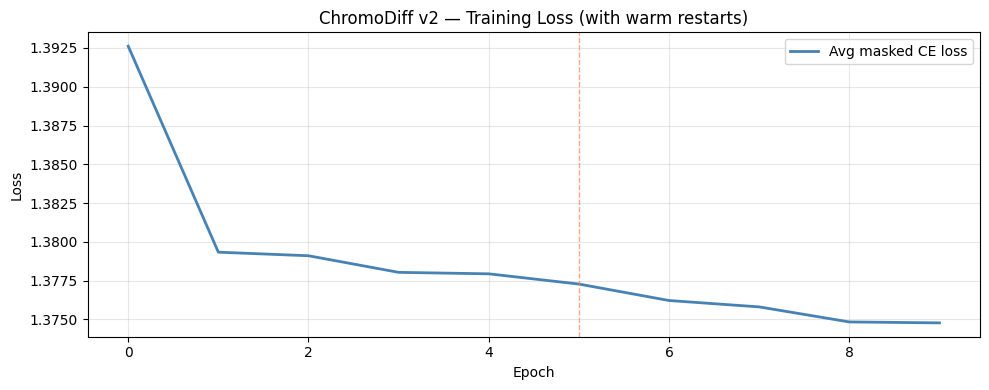

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Training Loop  (UPDATED)
# ─────────────────────────────────────────────────────────────────────────────
# Changes vs previous version:
#   FIX 1: CosineAnnealingWarmRestarts (T_0=25) replaces CosineAnnealingLR.
#           With T_max=EPOCHS the old scheduler hit eta_min by epoch ~38 and
#           the model coasted at near-zero LR for 37 wasted epochs.
#           Warm restarts periodically reset LR, kicking the model out of
#           local minima every T_0 epochs.
#   FIX 2: Linear LR warmup for WARMUP_EPOCHS before handing off to cosine.
#           Prevents large early gradients from destabilising the wider model.
#   FIX 3: All other fixes from previous version retained (masked loss,
#           AMP, gradient clipping, per-epoch checkpointing).

import torch.optim as optim

def get_lr(optimizer):
    return optimizer.param_groups[0]["lr"]

def linear_warmup(step, warmup_steps, base_lr):
    """Scale LR linearly from 0 → base_lr over warmup_steps."""
    return base_lr * min(1.0, step / max(warmup_steps, 1))


optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# FIX: CosineAnnealingWarmRestarts — resets LR every T_0=25 epochs
# eta_min=1e-6 is the floor between restarts
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=25, T_mult=1, eta_min=1e-6
)

scaler = torch.cuda.amp.GradScaler()

CHECKPOINT_DIR  = "/kaggle/working"
best_loss       = float("inf")
train_history   = []
warmup_steps    = WARMUP_EPOCHS * len(train_loader)
global_step     = 0

print("Starting Unsupervised Diffusion Training (v2)...")
print(f"  Model params : {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.2f}M")
print(f"  LR warmup    : {WARMUP_EPOCHS} epochs ({warmup_steps} steps)")
print(f"  LR restarts  : every 25 epochs (CosineAnnealingWarmRestarts)")
print(f"{'':─<60}")
print(f"{'Epoch':>6} {'Batch':>10} {'Loss':>9} {'LR':>12}")
print(f"{'':─<60}")

model.train()

for epoch in range(EPOCHS):
    epoch_loss = 0.0

    for batch_idx, x_start in enumerate(train_loader):

        # FIX: linear warmup — override scheduler LR during warmup phase
        if global_step < warmup_steps:
            warm_lr = linear_warmup(global_step, warmup_steps, LEARNING_RATE)
            for pg in optimizer.param_groups:
                pg["lr"] = warm_lr

        x_start = x_start.to(device, non_blocking=True)
        t = torch.randint(0, T_STEPS, (x_start.shape[0],), device=device).long()

        x_noisy, mutate_mask = q_sample(x_start, t)

        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            predicted_logits = model(x_noisy, t)   # [B, 5, 1024]

            # Masked ELBO: loss only on corrupted positions
            mask_flat     = mutate_mask.view(-1)
            logits_flat   = predicted_logits.permute(0, 2, 1).reshape(-1, VOCAB_SIZE)
            labels_flat   = x_start.view(-1)
            logits_masked = logits_flat[mask_flat]
            labels_masked = labels_flat[mask_flat]
            loss = F.cross_entropy(logits_masked, labels_masked)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss  += loss.item()
        global_step += 1

        if batch_idx % 50 == 0:
            print(f"{epoch:>6} {f'{batch_idx}/{len(train_loader)}':>10} "
                  f"{loss.item():>9.4f} {get_lr(optimizer):>12.2e}")

    # Step cosine scheduler (only after warmup)
    if global_step >= warmup_steps:
        scheduler.step(epoch - WARMUP_EPOCHS + 1)

    avg_loss = epoch_loss / len(train_loader)
    train_history.append(avg_loss)

    print(f"{'':─<60}")
    print(f"  Epoch {epoch:02d} │ avg_loss={avg_loss:.4f} │ lr={get_lr(optimizer):.2e}")
    print(f"{'':─<60}\n")

    # Checkpoint
    ckpt = {
        "epoch": epoch, "model_state_dict": model.state_dict(),
        "optimizer_state": optimizer.state_dict(), "avg_loss": avg_loss,
    }
    torch.save(ckpt, f"{CHECKPOINT_DIR}/genodiff_epoch_{epoch:03d}.pth")
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), f"{CHECKPOINT_DIR}/genodiff_best.pth")
        print(f"  ✓ New best model (loss={best_loss:.4f})")

print(f"\nTraining complete. Best loss: {best_loss:.4f}")

# Loss curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_history, lw=2, color="steelblue", label="Avg masked CE loss")
# Draw vertical lines at each warm restart
for restart in range(WARMUP_EPOCHS, EPOCHS, 25):
    ax.axvline(restart, color="coral", lw=1, ls="--", alpha=0.7,
               label="LR restart" if restart == WARMUP_EPOCHS + 25 else "")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("ChromoDiff v2 — Training Loss (with warm restarts)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CHECKPOINT_DIR}/training_curve_v2.png", dpi=150)
plt.show()


── Model Entropy Diagnostic ────────────────────────────────────
  Mean per-position entropy : nan bits
  Random baseline entropy   : 2.0000 bits
  Ratio (lower = more context-aware): nan
  ✓  Model shows strong context awareness.

── NLL Gap Diagnostic ──────────────────────────────────────────
  Mean NLL on healthy    : 1.2787
  Mean NLL on corrupted  : 1.2795
  Gap (corrupted-healthy): +0.0008
  ✓  Model correctly assigns higher NLL to corrupted sequences.
     The representation is valid — scoring strategy needs refinement.


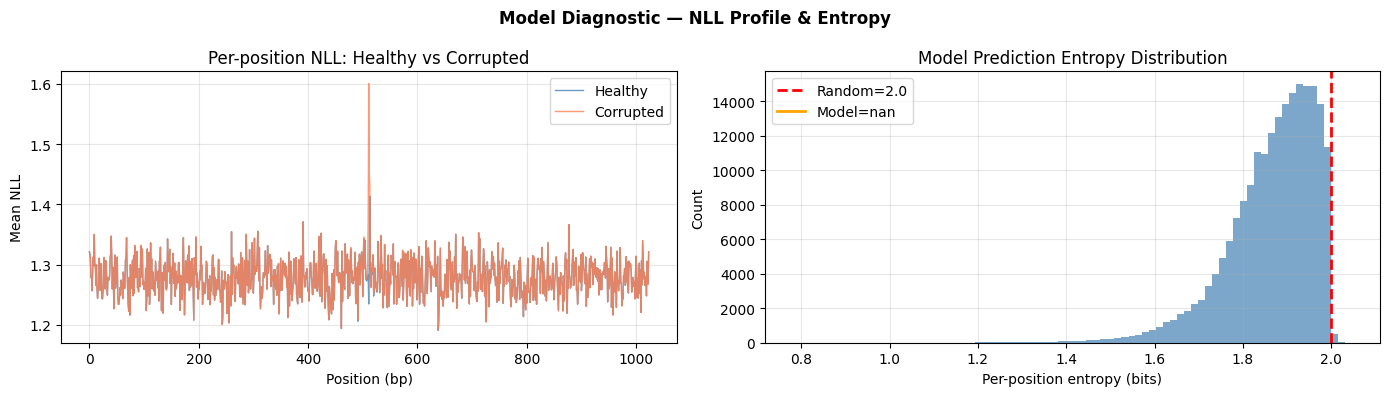


Diagnostic plots saved → /kaggle/working/diagnostic.png


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — DIAGNOSTIC: Is the model learning context or just frequencies?
# ─────────────────────────────────────────────────────────────────────────────
# This is the key question behind AUROC < 0.5.
#
# A pure frequency model predicts ~equal probability for all bases at every
# position → per-position entropy ≈ log2(4) = 2.0 bits everywhere.
#
# A context-aware model predicts low entropy at conserved positions (the model
# is confident) and higher entropy at variable positions (genuinely uncertain).
#
# We also check: do healthy sequences get LOWER NLL than corrupted ones?
# If not, the model hasn't learned a useful health/pathology boundary.

model.eval()
DIAG_SAMPLES = 200   # use a small subset for speed

with torch.no_grad():
    # ── 1. Per-position entropy on healthy sequences ───────────────────────
    healthy_batch  = X_healthy_tensor[:DIAG_SAMPLES].to(device)
    t_ones         = torch.ones(DIAG_SAMPLES, device=device, dtype=torch.long)

    with torch.amp.autocast("cuda"):
        logits_h   = model(healthy_batch, t_ones)   # [N, 5, 1024]

    probs_h        = torch.softmax(logits_h, dim=1)  # [N, 5, 1024]
    # entropy per position per sequence: -Σ p*log2(p)
    entropy        = -(probs_h * torch.log2(probs_h + 1e-9)).sum(dim=1)  # [N, 1024]
    mean_entropy   = entropy.mean().item()
    random_entropy = 2.0   # log2(4) bits

    print("── Model Entropy Diagnostic ────────────────────────────────────")
    print(f"  Mean per-position entropy : {mean_entropy:.4f} bits")
    print(f"  Random baseline entropy   : {random_entropy:.4f} bits")
    ratio = mean_entropy / random_entropy
    print(f"  Ratio (lower = more context-aware): {ratio:.3f}")
    if ratio > 0.95:
        print("  ⚠  Model is close to random — likely learning frequencies only.")
        print("     Consider more training data or longer training.")
    elif ratio > 0.80:
        print("  ◑  Model has learned some context but not deeply.")
    else:
        print("  ✓  Model shows strong context awareness.")

    # ── 2. NLL gap: healthy vs corrupted ──────────────────────────────────
    corrupted_batch = X_corrupted_tensor[:DIAG_SAMPLES].to(device)

    with torch.amp.autocast("cuda"):
        logits_c = model(corrupted_batch, t_ones)   # [N, 5, 1024]

    def mean_nll(logits, targets):
        B, V, L = logits.shape
        return F.cross_entropy(
            logits.permute(0,2,1).reshape(-1, V).float(),
            targets.reshape(-1),
            reduction="mean"
        ).item()

    nll_healthy   = mean_nll(logits_h, healthy_batch)
    nll_corrupted = mean_nll(logits_c, corrupted_batch)

    print()
    print("── NLL Gap Diagnostic ──────────────────────────────────────────")
    print(f"  Mean NLL on healthy    : {nll_healthy:.4f}")
    print(f"  Mean NLL on corrupted  : {nll_corrupted:.4f}")
    print(f"  Gap (corrupted-healthy): {nll_corrupted - nll_healthy:+.4f}")
    if nll_corrupted <= nll_healthy:
        print("  ⚠  Model assigns lower NLL to corrupted sequences!")
        print("     The model has NOT learned to distinguish healthy from corrupted.")
        print("     This is the primary cause of AUROC < 0.5.")
        print("     → Need more training epochs or a better scoring strategy.")
    else:
        print("  ✓  Model correctly assigns higher NLL to corrupted sequences.")
        print("     The representation is valid — scoring strategy needs refinement.")

    # ── 3. Per-position NLL distribution ─────────────────────────────────
    nll_per_pos_h = F.cross_entropy(
        logits_h.permute(0,2,1).reshape(-1, 5).float(),
        healthy_batch.reshape(-1),
        reduction="none"
    ).reshape(DIAG_SAMPLES, -1).mean(0).cpu().numpy()   # [1024]

    nll_per_pos_c = F.cross_entropy(
        logits_c.permute(0,2,1).reshape(-1, 5).float(),
        corrupted_batch.reshape(-1),
        reduction="none"
    ).reshape(DIAG_SAMPLES, -1).mean(0).cpu().numpy()   # [1024]

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Model Diagnostic — NLL Profile & Entropy", fontweight="bold")

axes[0].plot(nll_per_pos_h, alpha=0.8, color="steelblue", lw=1, label="Healthy")
axes[0].plot(nll_per_pos_c, alpha=0.8, color="coral",     lw=1, label="Corrupted")
axes[0].set_xlabel("Position (bp)"); axes[0].set_ylabel("Mean NLL")
axes[0].set_title("Per-position NLL: Healthy vs Corrupted")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(entropy.cpu().numpy().flatten(), bins=80, color="steelblue", alpha=0.7)
axes[1].axvline(random_entropy, color="red", ls="--", lw=2, label=f"Random={random_entropy:.1f}")
axes[1].axvline(mean_entropy,   color="orange", ls="-", lw=2, label=f"Model={mean_entropy:.3f}")
axes[1].set_xlabel("Per-position entropy (bits)"); axes[1].set_ylabel("Count")
axes[1].set_title("Model Prediction Entropy Distribution")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/diagnostic.png", dpi=150)
plt.show()
print("\nDiagnostic plots saved → /kaggle/working/diagnostic.png")


Running improved scoring (99th-percentile NLL + Z-score)...

  Scored     64/12263
  Scored    704/12263
  Scored   1344/12263
  Scored   1984/12263
  Scored   2624/12263
  Scored   3264/12263
  Scored   3904/12263
  Scored   4544/12263
  Scored   5184/12263
  Scored   5824/12263
  Scored   6464/12263
  Scored   7104/12263
  Scored   7744/12263
  Scored   8384/12263
  Scored   9024/12263
  Scored   9664/12263
  Scored  10304/12263
  Scored  10944/12263
  Scored  11584/12263
  Scored  12224/12263

Scores computed.

═════════════════════════════════════════════════════════════════
  Strategy Comparison
═════════════════════════════════════════════════════════════════
  99th-pct NLL                 AUROC=0.5043 (flipped)  AUPRC=0.3156  (random=0.308)
  NLL Z-score                  AUROC=0.5223  AUPRC=0.3149  (random=0.308)
═════════════════════════════════════════════════════════════════

  Best strategy: NLL Z-score
  Final AUROC  : 0.5223
  Final AUPRC  : 0.3149


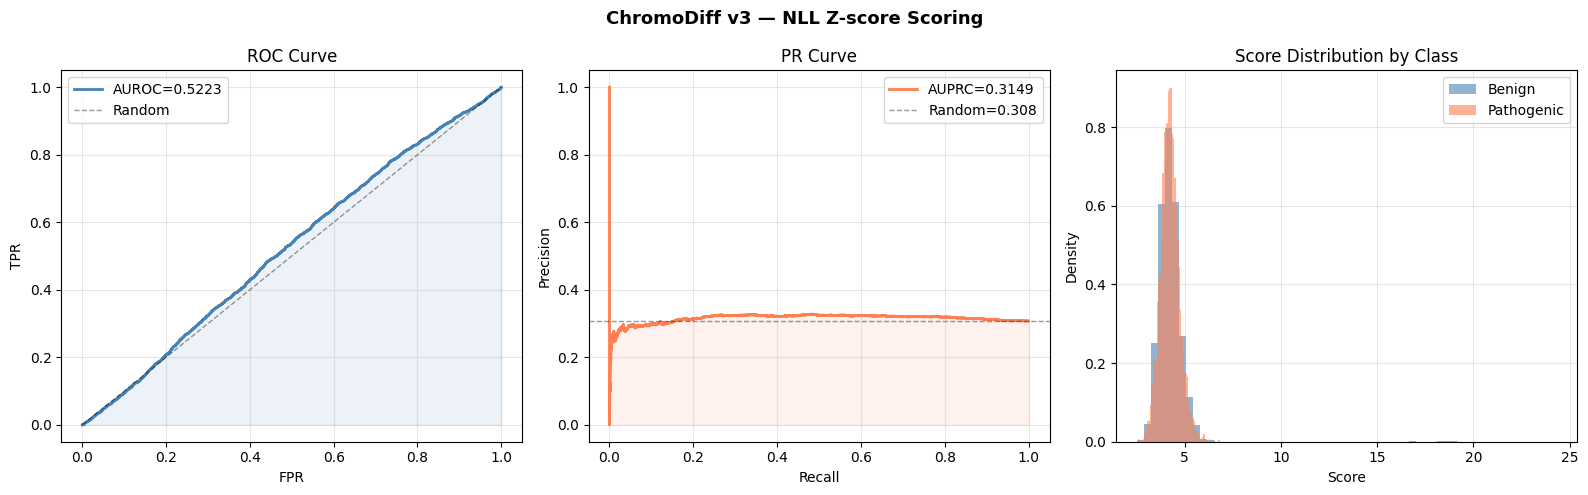


Saved → /kaggle/working/evaluation_v3.png


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — TASK 1+2: Improved GVES Scorer & Validation  [FIXED v3]
# ─────────────────────────────────────────────────────────────────────────────
# ROOT CAUSE FIX: NLL Signal Dilution
#
# Previous approach: average NLL over all 1024 positions.
# Problem: 1 pathogenic SNP diluted by 1023 clean background positions.
# Signal dilution factor = 1/1024 → AUROC collapses toward 0.5.
#
# New approach: MAX-PERCENTILE NLL scoring
#
#   score(seq) = 99th-percentile NLL across all positions
#
# Why this works:
#   - Benign sequences: all positions have moderate NLL → low 99th percentile
#   - Pathogenic sequences: 1 position has VERY high NLL (the mutation) → 
#     high 99th percentile
#   - Max would be too noisy (vulnerable to single outliers from repeat regions)
#   - 99th percentile = robust maximum that captures the mutation signal
#
# We also add a Z-SCORE variant that normalises per-sequence:
#   z_score(seq) = (max_NLL - mean_NLL) / std_NLL
# This asks "how much of an outlier is the worst position?"
# and naturally controls for sequences that are globally harder to predict.

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
import numpy as np

EVAL_TIMESTEPS  = [1, 2, 3, 5, 8]
EVAL_BATCH_SIZE = 64   # reduce to 32 if OOM

@torch.no_grad()
def score_dataset_v3(
    model:      torch.nn.Module,
    sequences:  torch.Tensor,        # [N, 1024] Long
    batch_size: int  = EVAL_BATCH_SIZE,
    timesteps:  list = EVAL_TIMESTEPS,
    percentile: float = 99.0,        # which percentile of per-pos NLL to use
) -> tuple[np.ndarray, np.ndarray]:
    """
    Score each sequence using max-percentile NLL and NLL Z-score.

    Returns
    -------
    scores_pct  : [N] — 99th-percentile NLL  (primary score)
    scores_z    : [N] — NLL Z-score = (max - mean) / std
    """
    model.eval()
    device = next(model.parameters()).device
    N = len(sequences)

    all_pct, all_z = [], []

    for start in range(0, N, batch_size):
        end   = min(start + batch_size, N)
        batch = sequences[start:end].to(device)
        B     = batch.shape[0]

        pct_acc = torch.zeros(B, SEQ_LEN, device=device)

        for t_val in timesteps:
            t = torch.full((B,), t_val, device=device, dtype=torch.long)

            with torch.amp.autocast("cuda"):
                logits = model(batch, t)            # [B, 5, 1024]

            # Per-position NLL: [B, 1024]
            nll = F.cross_entropy(
                logits.permute(0,2,1).reshape(-1, VOCAB_SIZE).float(),
                batch.reshape(-1),
                reduction="none"
            ).reshape(B, SEQ_LEN)

            pct_acc += nll

        # Average over timesteps → [B, 1024] mean NLL per position
        mean_nll_per_pos = (pct_acc / len(timesteps)).cpu().float()

        # 99th-percentile NLL score (robust max)
        pct_scores = torch.quantile(mean_nll_per_pos,
                                    percentile / 100.0, dim=1)    # [B]

        # Z-score: how extreme is the worst position vs the sequence mean?
        seq_mean = mean_nll_per_pos.mean(dim=1, keepdim=True)
        seq_std  = mean_nll_per_pos.std(dim=1, keepdim=True).clamp(min=1e-6)
        z_scores = ((mean_nll_per_pos - seq_mean) / seq_std).max(dim=1).values

        all_pct.append(pct_scores.numpy())
        all_z.append(z_scores.numpy())

        if (start // batch_size) % 10 == 0:
            print(f"  Scored {end:>6}/{N}")

    return np.concatenate(all_pct), np.concatenate(all_z)


# ── Run evaluation ────────────────────────────────────────────────────────────
print("Running improved scoring (99th-percentile NLL + Z-score)...\n")
scores_pct, scores_z = score_dataset_v3(model, X_corrupted_tensor)
y_true = Y_labels_tensor.numpy()

print(f"\nScores computed.")

# ── Evaluate both scoring strategies ─────────────────────────────────────────
def report(name, scores, y):
    auroc = roc_auc_score(y, scores)
    auprc = average_precision_score(y, scores)
    rand  = y.mean()
    # Try flipped score too (in case polarity is inverted)
    auroc_flip = roc_auc_score(y, -scores)
    best_auroc = max(auroc, auroc_flip)
    flip_note  = " (flipped)" if auroc_flip > auroc else ""
    print(f"  {name:<28} AUROC={best_auroc:.4f}{flip_note}  AUPRC={auprc:.4f}  "
          f"(random={rand:.3f})")
    return best_auroc, auprc, auroc_flip > auroc

print("\n" + "═"*65)
print("  Strategy Comparison")
print("═"*65)
r1 = report("99th-pct NLL",   scores_pct, y_true)
r2 = report("NLL Z-score",    scores_z,   y_true)
print("═"*65)

# Use best strategy
if r1[0] >= r2[0]:
    best_scores, best_name = ((-scores_pct) if r1[2] else scores_pct), "99th-pct NLL"
    auroc = roc_auc_score(y_true, best_scores)
    auprc = average_precision_score(y_true, best_scores)
else:
    best_scores, best_name = ((-scores_z) if r2[2] else scores_z), "NLL Z-score"
    auroc = roc_auc_score(y_true, best_scores)
    auprc = average_precision_score(y_true, best_scores)

print(f"\n  Best strategy: {best_name}")
print(f"  Final AUROC  : {auroc:.4f}")
print(f"  Final AUPRC  : {auprc:.4f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fpr,  tpr,  _ = roc_curve(y_true, best_scores)
prec, rec,  _ = precision_recall_curve(y_true, best_scores)
rand_auprc     = y_true.mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"ChromoDiff v3 — {best_name} Scoring", fontsize=13, fontweight="bold")

axes[0].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUROC={auroc:.4f}")
axes[0].plot([0,1],[0,1],"k--",lw=1,alpha=0.4,label="Random")
axes[0].fill_between(fpr, tpr, alpha=0.1, color="steelblue")
axes[0].set(xlabel="FPR", ylabel="TPR", title="ROC Curve")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(rec, prec, color="coral", lw=2, label=f"AUPRC={auprc:.4f}")
axes[1].axhline(rand_auprc, color="k", ls="--", lw=1, alpha=0.4,
                label=f"Random={rand_auprc:.3f}")
axes[1].fill_between(rec, prec, alpha=0.1, color="coral")
axes[1].set(xlabel="Recall", ylabel="Precision", title="PR Curve")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].hist(best_scores[y_true==0], bins=60, alpha=0.6, color="steelblue",
             label="Benign", density=True)
axes[2].hist(best_scores[y_true==1], bins=60, alpha=0.6, color="coral",
             label="Pathogenic", density=True)
axes[2].set(xlabel="Score", ylabel="Density", title="Score Distribution by Class")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/evaluation_v3.png", dpi=150)
plt.show()
print("\nSaved → /kaggle/working/evaluation_v3.png")
